
# Ejercicios: Familias de CNN (Inception, ResNet, MobileNet, U-Net) vs CNN “normal”

Objetivo del cuaderno:
- Entrenar una **CNN baseline** (conv + pooling).
- Implementar versiones educativas (pequeñas) de:
  - **Inception** (multi-escala en paralelo)
  - **ResNet** (conexiones residuales / skip)
  - **MobileNet** (depthwise separable conv)
  - **U-Net** (encoder–decoder con skips para segmentación)
- Compararlas en **parámetros**, **tiempo por época** y **métricas**.

> Por defecto va en modo rápido (`FAST_MODE=True`). Puedes subir épocas/datos.


## 0) Setup

In [1]:

# !pip -q install tensorflow matplotlib pandas

import time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

SEED = 42
tf.keras.utils.set_random_seed(SEED)

FAST_MODE = True
EPOCHS = 5 if FAST_MODE else 20
BATCH_SIZE = 128
TRAIN_N = 30000 if FAST_MODE else None
VAL_N   = 5000 if FAST_MODE else None
TEST_N  = None

try:
    tf.config.optimizer.set_jit(True)
except Exception:
    pass


2026-03-16 12:39:53.601628: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 12:39:53.898842: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-16 12:39:53.898860: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-03-16 12:39:53.950937: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 12:39:54.808947: W tensorflow/stream_executor/platform/de

TF: 2.10.0
GPUs: []


2026-03-16 12:39:55.929082: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-03-16 12:39:55.930012: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-03-16 12:39:55.930306: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-03-16 12:39:55.930382: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-03-16 12:39:55.930448: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Co

## 1) Dataset común (CIFAR-10) para clasificación

Train: (30000, 32, 32, 3) (30000,)
Val  : (5000, 32, 32, 3) (5000,)
Test : (10000, 32, 32, 3) (10000,)


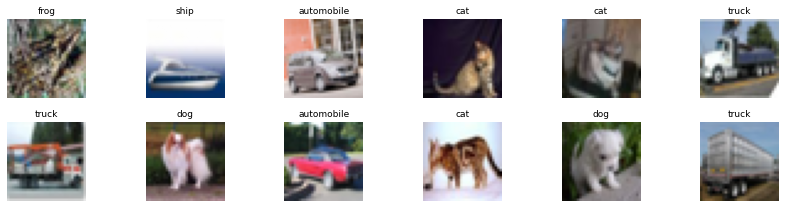

In [2]:

from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.squeeze()
y_test  = y_test.squeeze()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

VAL_SIZE = 5000
x_val, y_val = x_train[-VAL_SIZE:], y_train[-VAL_SIZE:]
x_tr,  y_tr  = x_train[:-VAL_SIZE], y_train[:-VAL_SIZE]

if TRAIN_N is not None:
    x_tr, y_tr = x_tr[:TRAIN_N], y_tr[:TRAIN_N]
if VAL_N is not None:
    x_val, y_val = x_val[:VAL_N], y_val[:VAL_N]
if TEST_N is not None:
    x_test, y_test = x_test[:TEST_N], y_test[:TEST_N]

CLASS_NAMES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("Train:", x_tr.shape, y_tr.shape)
print("Val  :", x_val.shape, y_val.shape)
print("Test :", x_test.shape, y_test.shape)

idx = np.random.default_rng(SEED).choice(len(x_tr), size=12, replace=False)
plt.figure(figsize=(12,3))
for i, j in enumerate(idx):
    plt.subplot(2,6,i+1)
    plt.imshow(x_tr[j])
    plt.title(CLASS_NAMES[int(y_tr[j])], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 2) Helpers: entrenamiento y comparación

In [3]:

def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def train_and_eval(model, name, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3):
    compile_model(model, lr=lr)
    callbacks = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)]

    t0 = time.time()
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks
    )
    t_train = time.time() - t0

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    params = int(model.count_params())

    row = {
        "model": name,
        "params": params,
        "train_time_s": round(float(t_train), 2),
        "sec_per_epoch": round(float(t_train) / max(1, len(history.epoch)), 2),
        "best_val_acc": round(float(max(history.history.get("val_accuracy",[float('nan')]))), 4),
        "test_acc": round(float(test_acc), 4),
    }
    return row, history

def plot_histories(histories_dict, metric="val_accuracy", title=None):
    plt.figure(figsize=(7,4))
    for name, h in histories_dict.items():
        if metric in h.history:
            plt.plot(h.history[metric], label=name)
    plt.xlabel("epoch")
    plt.ylabel(metric)
    if title: plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



# Parte A — Clasificación: CNN “normal” vs Inception / ResNet / MobileNet

Todas las redes entrenan sobre **CIFAR-10** y luego comparamos.



## A1) CNN baseline (conv + pooling)
**Qué haremos:** Entrenamos una CNN clásica y la usamos como referencia.
**Ejercicio:** prueba a variar `base_filters` o añadir/quitar dropout.


In [4]:

def build_baseline_cnn(input_shape=(32,32,3), num_classes=10, base_filters=32, dropout=0.25):
    inp = keras.Input(shape=input_shape)
    x = inp
    for b in range(3):
        f = base_filters * (2**b)
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="baseline_cnn")

histories = {}
results = []

baseline = build_baseline_cnn(base_filters=32, dropout=0.25)
row, h = train_and_eval(baseline, "Baseline CNN")
results.append(row); histories["Baseline CNN"] = h

pd.DataFrame(results)


2026-03-13 12:43:33.355883: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/5


2026-03-13 12:43:34.241893: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 368640000 exceeds 10% of free system memory.
2026-03-13 12:43:34.614857: W tensorflow/compiler/jit/mark_for_compilation_pass.cc:1780] (One-time warning): Not using XLA:CPU for cluster.

If you want XLA:CPU, do one of the following:

 - set the TF_XLA_FLAGS to include "--tf_xla_cpu_global_jit", or
 - set cpu_global_jit to true on this session's OptimizerOptions, or
 - use experimental_jit_scope, or
 - use tf.function(jit_compile=True).

To confirm that XLA is active, pass --vmodule=xla_compilation_cache=1 (as a
proper command-line flag, not via TF_XLA_FLAGS).


235/235 [==============================] - ETA: 0s - loss: 1.8017 - accuracy: 0.3229

2026-03-13 12:44:13.104614: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 61440000 exceeds 10% of free system memory.


235/235 [==============================] - 40s 166ms/step - loss: 1.8017 - accuracy: 0.3229 - val_loss: 1.4687 - val_accuracy: 0.4490
Epoch 2/5
235/235 [==============================] - 38s 161ms/step - loss: 1.3844 - accuracy: 0.4932 - val_loss: 1.2239 - val_accuracy: 0.5628
Epoch 3/5
235/235 [==============================] - 38s 162ms/step - loss: 1.1783 - accuracy: 0.5744 - val_loss: 1.0328 - val_accuracy: 0.6370
Epoch 4/5
235/235 [==============================] - 39s 164ms/step - loss: 1.0428 - accuracy: 0.6262 - val_loss: 0.9171 - val_accuracy: 0.6762
Epoch 5/5
235/235 [==============================] - 38s 161ms/step - loss: 0.9438 - accuracy: 0.6641 - val_loss: 0.8513 - val_accuracy: 0.7042


2026-03-13 12:46:47.001982: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


,model,params,train_time_s,sec_per_epoch,best_val_acc,test_acc
0,Baseline CNN,814122,193.23,38.65,0.7042,0.6891



## A2) Inception (multi-escala en paralelo)
**Qué haremos:** Bloque tipo Inception con ramas 1×1, 3×3, “5×5” (2×3×3) y pooling en paralelo.
**Ejercicio:** cambia `base` y observa parámetros/accuracy.


In [5]:

def inception_block(x, f1=16, f3=16, f5=16, fp=16, name=None):
    b1 = layers.Conv2D(f1, 1, padding="same", activation="relu")(x)

    b2 = layers.Conv2D(f3, 1, padding="same", activation="relu")(x)
    b2 = layers.Conv2D(f3, 3, padding="same", activation="relu")(b2)

    b3 = layers.Conv2D(f5, 1, padding="same", activation="relu")(x)
    b3 = layers.Conv2D(f5, 3, padding="same", activation="relu")(b3)
    b3 = layers.Conv2D(f5, 3, padding="same", activation="relu")(b3)

    b4 = layers.MaxPooling2D(pool_size=3, strides=1, padding="same")(x)
    b4 = layers.Conv2D(fp, 1, padding="same", activation="relu")(b4)

    return layers.Concatenate(name=name)([b1, b2, b3, b4])

def build_inception_cnn(input_shape=(32,32,3), num_classes=10, base=16, dropout=0.25):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)

    x = inception_block(x, base, base, base, base, name="inc1")
    x = layers.MaxPooling2D()(x)

    x = inception_block(x, base*2, base*2, base*2, base*2, name="inc2")
    x = layers.MaxPooling2D()(x)

    x = inception_block(x, base*4, base*4, base*4, base*4, name="inc3")

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="inception_small")

inception = build_inception_cnn(base=16, dropout=0.25)
row, h = train_and_eval(inception, "Inception-small")
results.append(row); histories["Inception-small"] = h

pd.DataFrame(results).sort_values("test_acc", ascending=False)


Epoch 1/5


2026-03-13 12:49:53.078457: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 368640000 exceeds 10% of free system memory.


235/235 [==============================] - ETA: 0s - loss: 1.9191 - accuracy: 0.2699

2026-03-13 12:50:59.144651: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 61440000 exceeds 10% of free system memory.


235/235 [==============================] - 68s 284ms/step - loss: 1.9191 - accuracy: 0.2699 - val_loss: 1.6647 - val_accuracy: 0.3638
Epoch 2/5
235/235 [==============================] - 66s 280ms/step - loss: 1.5983 - accuracy: 0.4014 - val_loss: 1.4653 - val_accuracy: 0.4526
Epoch 3/5
235/235 [==============================] - 65s 278ms/step - loss: 1.4242 - accuracy: 0.4722 - val_loss: 1.3031 - val_accuracy: 0.5206
Epoch 4/5
235/235 [==============================] - 65s 278ms/step - loss: 1.3032 - accuracy: 0.5218 - val_loss: 1.2308 - val_accuracy: 0.5442
Epoch 5/5
235/235 [==============================] - 69s 293ms/step - loss: 1.1915 - accuracy: 0.5691 - val_loss: 1.2193 - val_accuracy: 0.5654


,model,params,train_time_s,sec_per_epoch,best_val_acc,test_acc
0,Baseline CNN,814122,193.23,38.65,0.7042,0.6891
1,Inception-small,192410,333.67,66.73,0.5654,0.5562



## A3) ResNet (bloques residuales)
**Qué haremos:** Bloque residual con skip connection para facilitar el entrenamiento de redes más profundas.
**Ejercicio:** añade más bloques por stage y compara.


In [ ]:

def residual_block(x, filters, downsample=False, name=None):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add(name=name)([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_resnet_small(input_shape=(32,32,3), num_classes=10, base_filters=32):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(base_filters, 3, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, base_filters, downsample=False, name="res1_1")
    x = residual_block(x, base_filters, downsample=False, name="res1_2")

    x = residual_block(x, base_filters*2, downsample=True, name="res2_1")
    x = residual_block(x, base_filters*2, downsample=False, name="res2_2")

    x = residual_block(x, base_filters*4, downsample=True, name="res3_1")
    x = residual_block(x, base_filters*4, downsample=False, name="res3_2")

    x = layers.GlobalAveragePooling2D()(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="resnet_small")

resnet = build_resnet_small(base_filters=32)
row, h = train_and_eval(resnet, "ResNet-small")
results.append(row); histories["ResNet-small"] = h

pd.DataFrame(results).sort_values("test_acc", ascending=False)


2026-03-16 12:50:33.198384: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/5


2026-03-16 12:50:34.134807: W tensorflow/compiler/jit/mark_for_compilation_pass.cc:1780] (One-time warning): Not using XLA:CPU for cluster.

If you want XLA:CPU, do one of the following:

 - set the TF_XLA_FLAGS to include "--tf_xla_cpu_global_jit", or
 - set cpu_global_jit to true on this session's OptimizerOptions, or
 - use experimental_jit_scope, or
 - use tf.function(jit_compile=True).

To confirm that XLA is active, pass --vmodule=xla_compilation_cache=1 (as a
proper command-line flag, not via TF_XLA_FLAGS).


235/235 [==============================] - 125s 527ms/step - loss: 1.3352 - accuracy: 0.5120 - val_loss: 2.5835 - val_accuracy: 0.1836
Epoch 2/5
235/235 [==============================] - 124s 529ms/step - loss: 0.9349 - accuracy: 0.6701 - val_loss: 1.5730 - val_accuracy: 0.4770
Epoch 3/5
235/235 [==============================] - 126s 535ms/step - loss: 0.7607 - accuracy: 0.7285 - val_loss: 1.4311 - val_accuracy: 0.5796
Epoch 4/5
235/235 [==============================] - 126s 534ms/step - loss: 0.6415 - accuracy: 0.7746 - val_loss: 1.1952 - val_accuracy: 0.6276
Epoch 5/5
102/235 [============>.................] - ETA: 1:09 - loss: 0.5180 - accuracy: 0.8244


## A4) MobileNet (Depthwise Separable Conv)
**Qué haremos:** DepthwiseConv2D + 1×1 Conv para reducir cómputo/parámetros.
**Ejercicio:** juega con `width_mult` y mira el trade-off accuracy/params.


In [ ]:

def ds_conv_block(x, filters, stride=1, name=None):
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(name=name)(x)
    return x

def build_mobilenet_small(input_shape=(32,32,3), num_classes=10, base_filters=32, width_mult=1.0, dropout=0.25):
    def wf(scale):
        return max(8, int(base_filters * scale * width_mult))

    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(wf(1), 3, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = ds_conv_block(x, wf(1), stride=1, name="ds1")
    x = ds_conv_block(x, wf(2), stride=2, name="ds2")
    x = ds_conv_block(x, wf(2), stride=1, name="ds3")
    x = ds_conv_block(x, wf(4), stride=2, name="ds4")
    x = ds_conv_block(x, wf(4), stride=1, name="ds5")

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="mobilenet_small")

mobilenet = build_mobilenet_small(base_filters=32, width_mult=1.0, dropout=0.25)
row, h = train_and_eval(mobilenet, "MobileNet-small")
results.append(row); histories["MobileNet-small"] = h

pd.DataFrame(results).sort_values("test_acc", ascending=False)



## A5) Comparación final (clasificación)
**Qué haremos:** tabla + gráficas de `val_accuracy` y `test_acc`.


In [ ]:

df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
df


In [ ]:

plot_histories(histories, metric="val_accuracy", title="Comparación: val_accuracy (CIFAR-10)")


In [ ]:

plt.figure(figsize=(7,3))
plt.bar(df["model"], df["test_acc"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("test accuracy")
plt.title("CIFAR-10: accuracy por arquitectura")
plt.tight_layout()
plt.show()



# Parte B — Segmentación: U-Net vs “segmentador simple” (dataset sintético)

Usamos un dataset sintético de formas (círculo/cuadrado) para evitar dependencias externas.
Compararemos un **FCN simple** (sin skips) con **U-Net** (con skips).



## B1) Dataset sintético de segmentación
**Qué haremos:** generamos imágenes y máscaras y las visualizamos.


In [ ]:

def make_shape_sample(img_size=64):
    img = np.zeros((img_size, img_size, 1), dtype=np.float32)
    mask = np.zeros((img_size, img_size, 1), dtype=np.float32)

    img += np.random.uniform(0.0, 0.15, size=img.shape).astype(np.float32)

    shape_type = np.random.choice(["circle", "square"])
    cx, cy = np.random.randint(img_size//4, 3*img_size//4, size=2)
    r = np.random.randint(img_size//8, img_size//4)

    yy, xx = np.mgrid[:img_size, :img_size]

    if shape_type == "circle":
        region = (xx - cx)**2 + (yy - cy)**2 <= r*r
    else:
        region = (np.abs(xx - cx) <= r) & (np.abs(yy - cy) <= r)

    mask[region, 0] = 1.0
    img[region, 0] += np.random.uniform(0.6, 0.9)
    img = np.clip(img, 0.0, 1.0)
    return img, mask

def make_dataset(n=2000, img_size=64):
    X = np.zeros((n, img_size, img_size, 1), dtype=np.float32)
    Y = np.zeros((n, img_size, img_size, 1), dtype=np.float32)
    for i in range(n):
        X[i], Y[i] = make_shape_sample(img_size)
    return X, Y

N = 2000 if FAST_MODE else 8000
IMG_SIZE = 64

X, Y = make_dataset(n=N, img_size=IMG_SIZE)
n_val = int(0.2 * N)
X_tr, Y_tr = X[:-n_val], Y[:-n_val]
X_va, Y_va = X[-n_val:], Y[-n_val:]

print("Train:", X_tr.shape, Y_tr.shape)
print("Val  :", X_va.shape, Y_va.shape)

k = 6
plt.figure(figsize=(12,4))
for i in range(k):
    plt.subplot(2,k,i+1)
    plt.imshow(X_tr[i,...,0], cmap="gray"); plt.axis("off"); plt.title("img")
    plt.subplot(2,k,k+i+1)
    plt.imshow(Y_tr[i,...,0], cmap="gray"); plt.axis("off"); plt.title("mask")
plt.tight_layout()
plt.show()



## B2) FCN simple vs U-Net (IoU)
**Qué haremos:** entrenamos ambos y comparamos IoU en validación.


In [ ]:

def iou_metric(y_true, y_pred, thr=0.5, eps=1e-7):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > thr, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true + y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + eps) / (union + eps))

class MeanIoUCallback(keras.callbacks.Callback):
    def __init__(self, Xv, Yv, name="val_iou"):
        super().__init__()
        self.Xv, self.Yv = Xv, Yv
        self.name = name
        self.iou_hist = []

    def on_epoch_end(self, epoch, logs=None):
        pred = self.model.predict(self.Xv, verbose=0)
        iou = float(iou_metric(self.Yv, pred).numpy())
        self.iou_hist.append(iou)
        print(f" — {self.name}: {iou:.4f}")

def build_fcn_simple(input_shape=(64,64,1)):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    out = layers.Conv2D(1, 1, activation="sigmoid")(x)
    return keras.Model(inp, out, name="fcn_simple")

def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
    return x

def build_unet(input_shape=(64,64,1), base=32):
    inp = keras.Input(shape=input_shape)

    c1 = conv_block(inp, base);   p1 = layers.MaxPooling2D()(c1)
    c2 = conv_block(p1, base*2);  p2 = layers.MaxPooling2D()(c2)
    c3 = conv_block(p2, base*4);  p3 = layers.MaxPooling2D()(c3)

    bn = conv_block(p3, base*8)

    u3 = layers.UpSampling2D()(bn)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, base*4)

    u2 = layers.UpSampling2D()(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, base*2)

    u1 = layers.UpSampling2D()(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, base)

    out = layers.Conv2D(1, 1, activation="sigmoid")(c6)
    return keras.Model(inp, out, name="unet")

def train_seg(model, epochs=8 if FAST_MODE else 25):
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy")
    cb = MeanIoUCallback(X_va, Y_va, name="val_iou")
    t0 = time.time()
    h = model.fit(X_tr, Y_tr, validation_data=(X_va, Y_va),
                  epochs=epochs, batch_size=64, verbose=1,
                  callbacks=[cb])
    t = time.time() - t0
    return h, cb.iou_hist, t

fcn = build_fcn_simple(input_shape=(IMG_SIZE,IMG_SIZE,1))
h_fcn, iou_fcn, t_fcn = train_seg(fcn)

unet = build_unet(input_shape=(IMG_SIZE,IMG_SIZE,1), base=32)
h_unet, iou_unet, t_unet = train_seg(unet)

seg_df = pd.DataFrame([
    {"model":"FCN-simple", "params": fcn.count_params(), "train_time_s": round(t_fcn,2), "best_val_iou": round(max(iou_fcn),4)},
    {"model":"U-Net",      "params": unet.count_params(), "train_time_s": round(t_unet,2), "best_val_iou": round(max(iou_unet),4)},
]).sort_values("best_val_iou", ascending=False)
seg_df



## B3) Visualización de predicciones
**Qué haremos:** mostramos imagen, máscara real y máscara predicha para FCN y U-Net.


In [ ]:

def show_seg_preds(model, X, Y, n=6, title=None):
    pred = model.predict(X[:n], verbose=0)
    plt.figure(figsize=(3*n, 6))
    for i in range(n):
        plt.subplot(3, n, i+1)
        plt.imshow(X[i,...,0], cmap="gray"); plt.axis("off"); plt.title("img")
        plt.subplot(3, n, n+i+1)
        plt.imshow(Y[i,...,0], cmap="gray"); plt.axis("off"); plt.title("mask")
        plt.subplot(3, n, 2*n+i+1)
        plt.imshow(pred[i,...,0] > 0.5, cmap="gray"); plt.axis("off"); plt.title("pred")
    if title: plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

show_seg_preds(fcn, X_va, Y_va, n=6, title="FCN-simple")
show_seg_preds(unet, X_va, Y_va, n=6, title="U-Net")



# Preguntas tipo examen (cierre)
1. Explica qué hace una conv **1×1** dentro de Inception.
2. ¿Por qué los bloques residuales ayudan a entrenar redes profundas?
3. ¿Qué separa una **Depthwise Separable Conv** y qué se gana?
4. ¿Qué papel tienen los **skips** en U-Net?
